# **Forecasting Taxi Demand Across NYC Zones**

# 1. Business Understanding

## Background

New York City's taxi industry is a vital part of the city's transportation network, known for its 
iconic yellow taxis and the more recently introduced green taxis. Yellow taxis are the 
traditional fleet seen across Manhattan and other boroughs, licensed for street hails and 
medallion services. In contrast, green taxis (often referred to as Boro Taxis) serve areas 
outside the core of Manhattan, primarily operating in the outer boroughs such as Queens, 
Brooklyn, and the Bronx, and have different fare structures and service regulations. 

## Objective

Develop a forecasting model that predicts the number of yellow taxi trips (or total revenue) 
for each NYC taxi zone on an hourly basis. This forecast will help optimize yellow taxi 
allocation, reduce passenger wait times, and improve overall urban mobility in New York 
City.

# 2. Data Understanding

In [1]:
#!pip install seaborn

In [118]:
import holidays
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

## Yellow Trip Data

In [3]:
# read january data for testing and breif checking
file_path = Path(
    r"C:\Users\semee\Desktop\calibraxTA\Dataset\yellow_tripdata_2023-01.parquet"
)

jan_df = pd.read_parquet(file_path)

print(jan_df.shape)
jan_df.head()

(3066766, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


In [4]:
jan_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            float64   

In [5]:
# check is there any missing values
missing = jan_df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

store_and_fwd_flag      71743
RatecodeID              71743
passenger_count         71743
airport_fee             71743
congestion_surcharge    71743
dtype: int64

In [6]:
# check the earliest and latest pickup time in jan dataset
print("Earliest pickup:", jan_df["tpep_pickup_datetime"].min())
print("Latest pickup:", jan_df["tpep_pickup_datetime"].max())

Earliest pickup: 2008-12-31 23:01:42
Latest pickup: 2023-02-01 00:56:53


Ok, now will only take columns that are seems necessary for demand forcasting for each month, and do a filter on invalid dates, then combine every month's parquet file.

In [7]:

data_path = Path(r"C:\Users\semee\Desktop\calibraxTA\Dataset")

files = sorted(data_path.glob("yellow_tripdata_2023-*.parquet"))

dfs = []

for file in files:
    print(f"Reading {file.name}...")

    temp = pd.read_parquet(
        file,
        
        # 2 columns that i need is the pickup time and location zone
        columns=[
            "tpep_pickup_datetime",
            "PULocationID"
        ]
    )

    # keep only timestamps within 2023
    temp = temp[
        (temp["tpep_pickup_datetime"] >= "2023-01-01") &
        (temp["tpep_pickup_datetime"] < "2024-01-01")
    ]

    dfs.append(temp)

# Combine all months
df = pd.concat(dfs, ignore_index=True)

print(f"\nTotal records: {len(df):,}")

Reading yellow_tripdata_2023-01.parquet...
Reading yellow_tripdata_2023-02.parquet...
Reading yellow_tripdata_2023-03.parquet...
Reading yellow_tripdata_2023-04.parquet...
Reading yellow_tripdata_2023-05.parquet...
Reading yellow_tripdata_2023-06.parquet...
Reading yellow_tripdata_2023-07.parquet...
Reading yellow_tripdata_2023-08.parquet...
Reading yellow_tripdata_2023-09.parquet...
Reading yellow_tripdata_2023-10.parquet...
Reading yellow_tripdata_2023-11.parquet...
Reading yellow_tripdata_2023-12.parquet...

Total records: 38,310,122


In [8]:
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 38310122 entries, 0 to 38310121
Data columns (total 2 columns):
 #   Column                Dtype         
---  ------                -----         
 0   tpep_pickup_datetime  datetime64[us]
 1   PULocationID          int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 584.6 MB
None


,tpep_pickup_datetime,PULocationID
0,2023-01-01 00:32:10,161
1,2023-01-01 00:55:08,43
2,2023-01-01 00:25:04,48
3,2023-01-01 00:03:48,138
4,2023-01-01 00:10:29,107


In [9]:
# check missing values
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .to_frame("Missing Values")
)

missing["Percentage"] = (
    missing["Missing Values"] / len(df) * 100
).round(2)

missing

,Missing Values,Percentage
tpep_pickup_datetime,0,0.0
PULocationID,0,0.0


In [10]:
# check any duplication
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates:,}")

Duplicate rows: 1,280,427


Duplication here does not necessary means dirty data, instead at the same zone there are different taxis picked up passengers at the same time, which is plausible in area like NYC

In [11]:
duplicates = df[df.duplicated(keep=False)]

duplicates.sort_values(
    ["tpep_pickup_datetime", "PULocationID"]
).head(20)

,tpep_pickup_datetime,PULocationID
1298,2023-01-01 00:02:59,234
1299,2023-01-01 00:02:59,234
3802,2023-01-01 00:03:04,142
4789,2023-01-01 00:03:04,142
4589,2023-01-01 00:04:11,141
4590,2023-01-01 00:04:11,141
4436,2023-01-01 00:04:20,237
4437,2023-01-01 00:04:20,237
2906,2023-01-01 00:05:30,264
2907,2023-01-01 00:05:30,264


In [12]:
print("Earliest pickup:", df["tpep_pickup_datetime"].min())
print("Latest pickup:", df["tpep_pickup_datetime"].max())

# Number of taxi zones
print("Unique Pickup Zones:", df["PULocationID"].nunique())

Earliest pickup: 2023-01-01 00:00:00
Latest pickup: 2023-12-31 23:59:59
Unique Pickup Zones: 263


In [13]:
# top 10 busiest zones
df["PULocationID"].value_counts().head(10)

PULocationID
132    1992276
237    1791793
161    1766037
236    1596582
162    1353751
138    1305253
186    1305112
230    1270677
142    1256021
170    1131671
Name: count, dtype: int64

In [14]:
# monthly trip distribution

df["month"] = df["tpep_pickup_datetime"].dt.month_name()
df["month"].value_counts().head(12)

month
October      3522269
May          3513664
March        3403660
December     3376527
November     3339731
June         3307259
April        3288248
January      3066726
February     2914003
July         2907093
September    2846741
August       2824201
Name: count, dtype: int64

In [15]:
# hourly trip distribution

df["hour"] = df["tpep_pickup_datetime"].dt.hour
df["hour"].value_counts()

hour
18    2704216
17    2581996
19    2416755
16    2374464
15    2371338
14    2311516
13    2157091
20    2153610
21    2151208
12    2090720
22    1994406
11    1925488
10    1773715
9     1632600
23    1581686
8     1446061
0     1088604
7     1044239
1      731321
6      532181
2      483366
3      319640
5      226410
4      217491
Name: count, dtype: int64

## Holiday Data

In [16]:
#!pip install holidays

In [17]:
# create a 2023 holiday table in the US from python library

us_holidays = holidays.US(years=[2023])

holiday_df = pd.DataFrame(
    {
        "date": list(us_holidays.keys()),
        "holiday_name": list(us_holidays.values())
    }
)

holiday_df["date"] = pd.to_datetime(holiday_df["date"])
holiday_df = holiday_df.sort_values("date").reset_index(drop=True)

holiday_df.head()

,date,holiday_name
0,2023-01-01,New Year's Day
1,2023-01-02,New Year's Day (observed)
2,2023-01-16,Martin Luther King Jr. Day
3,2023-02-20,Washington's Birthday
4,2023-05-29,Memorial Day


In [18]:
# add some label that might be useful in ML later
holiday_df["is_holiday"] = 1
holiday_df["day_of_week"] = holiday_df["date"].dt.day_name()
holiday_df["month"] = holiday_df["date"].dt.month_name()

holiday_df.head()

,date,holiday_name,is_holiday,day_of_week,month
0,2023-01-01,New Year's Day,1,Sunday,January
1,2023-01-02,New Year's Day (observed),1,Monday,January
2,2023-01-16,Martin Luther King Jr. Day,1,Monday,January
3,2023-02-20,Washington's Birthday,1,Monday,February
4,2023-05-29,Memorial Day,1,Monday,May


In [19]:
holiday_df.info()
print("Number of holidays:", len(holiday_df))

# there are only around 13– US federal holidays in year 2023

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype        
---  ------        --------------  -----        
 0   date          13 non-null     datetime64[s]
 1   holiday_name  13 non-null     str          
 2   is_holiday    13 non-null     int64        
 3   day_of_week   13 non-null     str          
 4   month         13 non-null     str          
dtypes: datetime64[s](1), int64(1), str(3)
memory usage: 1.0 KB
Number of holidays: 13


## Weather Data

Temperature dataset at Central Park New York, downloaded from https://www.ncei.noaa.gov/access/past-weather/Central%20Park

Since could not find hourly weather data for NYC,so daily weather observations were merged with the hourly taxi demand data based on the date in this scenario for this assessment. 
Therefore all hours within the same day will share the same weather conditions

In [20]:
weather_df = pd.read_csv(
    r"C:\Users\semee\Desktop\calibraxTA\Dataset\central_park_temp_data.csv"
)

weather_df.head(3)

,Date,TAVG (Degrees Fahrenheit),TMAX (Degrees Fahrenheit),TMIN (Degrees Fahrenheit),PRCP (Inches),SNOW (Inches),SNWD (Inches)
0,1869-01-01,NaN,29.0,19.0,0.75,9.0,NaN
1,1869-01-02,NaN,27.0,21.0,0.03,0.0,NaN
2,1869-01-03,NaN,35.0,27.0,0.00,0.0,NaN


In [21]:
# Convert mixed date formats safely, as there are date in format like 1/1/1900, and only keep 2023 data

# date parsing
weather_df["Date"] = pd.to_datetime(
    weather_df["Date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

# Check whether any dates failed to convert
print("Invalid dates:", weather_df["Date"].isna().sum())

# Remove rows with invalid dates, if any
weather_df = weather_df.dropna(subset=["Date"])

# Keep only 2023 data
weather_df = weather_df[
    (weather_df["Date"] >= "2023-01-01") &
    (weather_df["Date"] < "2024-01-01")
].copy()


Invalid dates: 0


In [22]:
# Only take this 4 columns, date, maximum & minimum temperature and precipitation
weather_df = weather_df[
    [
        "Date",
        "TMAX (Degrees Fahrenheit)",
        "TMIN (Degrees Fahrenheit)",
        "PRCP (Inches)"
    ]
].copy()

In [23]:
weather_df.head()

,Date,TMAX (Degrees Fahrenheit),TMIN (Degrees Fahrenheit),PRCP (Inches)
56247,2023-01-01,55.0,49.0,0.00
56248,2023-01-02,56.0,49.0,0.02
56249,2023-01-03,58.0,47.0,0.42
56250,2023-01-04,66.0,49.0,0.02
56251,2023-01-05,50.0,44.0,0.01


In [24]:
weather_df.shape
weather_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 56247 to 56611
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       365 non-null    datetime64[us]
 1   TMAX (Degrees Fahrenheit)  365 non-null    float64       
 2   TMIN (Degrees Fahrenheit)  365 non-null    float64       
 3   PRCP (Inches)              365 non-null    float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 11.5 KB


In [25]:
print(weather_df.isnull().sum())
print("********")
print("Min Date:",weather_df["Date"].min())
print("Max Date:",weather_df["Date"].max())
print("Number of days:", len(weather_df))
print("Duplication:",weather_df["Date"].duplicated().sum())

Date                         0
TMAX (Degrees Fahrenheit)    0
TMIN (Degrees Fahrenheit)    0
PRCP (Inches)                0
dtype: int64
********
Min Date: 2023-01-01 00:00:00
Max Date: 2023-12-31 00:00:00
Number of days: 365
Duplication: 0


<Axes: >

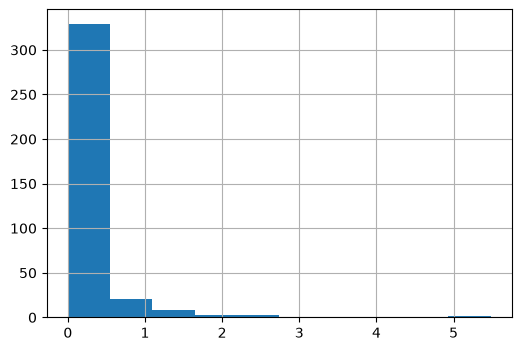

In [26]:
weather_df["PRCP (Inches)"].hist(figsize=(6,4))

# 3. Data Preparation

## Taxi Data Processing

First convert all individual trips into hourly demand per zone

In [27]:
# create pickup hour
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.floor("h")

In [28]:
# Aggregate taxi trips into hourly demand per pickup zone so each row in the original dataset represents one taxi trip
# Grouping by pickup_hour and PULocationID, then using .size() to counts the total number of trips occurring in each zone during each hour
# The trip_count is the target variable for forecasting

hourly_df = (
    df.groupby(["pickup_hour", "PULocationID"])
      .size()
      .reset_index(name="trip_count")
)

In [29]:
hourly_df["pickup_hour"].head(10).tolist()

[Timestamp('2023-01-01 00:00:00'),
 Timestamp('2023-01-01 00:00:00'),
 Timestamp('2023-01-01 00:00:00'),
 Timestamp('2023-01-01 00:00:00'),
 Timestamp('2023-01-01 00:00:00'),
 Timestamp('2023-01-01 00:00:00'),
 Timestamp('2023-01-01 00:00:00'),
 Timestamp('2023-01-01 00:00:00'),
 Timestamp('2023-01-01 00:00:00'),
 Timestamp('2023-01-01 00:00:00')]

In [30]:
hourly_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 886277 entries, 0 to 886276
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   pickup_hour   886277 non-null  datetime64[us]
 1   PULocationID  886277 non-null  int64         
 2   trip_count    886277 non-null  int64         
dtypes: datetime64[us](1), int64(2)
memory usage: 20.3 MB


In [31]:
print(hourly_df["pickup_hour"].min())
print(hourly_df["pickup_hour"].max())

2023-01-01 00:00:00
2023-12-31 23:00:00


## Data Merging

**Here combine Weather data to Taxi data**

In [32]:
# modify column name
weather_df = weather_df.rename(columns={"Date": "date"})

In [33]:
# create a new column date from pickup_hour that only take the date
hourly_df["date"] = hourly_df["pickup_hour"].dt.normalize()

In [34]:
# merging Weather and Taxi dataset
hourly_df = hourly_df.merge(
    weather_df,
    on="date",
    how="left"
)

In [35]:
hourly_df.tail()

,pickup_hour,PULocationID,trip_count,date,TMAX (Degrees Fahrenheit),TMIN (Degrees Fahrenheit),PRCP (Inches)
886272,2023-12-31 23:00:00,261,19,2023-12-31,43.0,39.0,0.0
886273,2023-12-31 23:00:00,262,54,2023-12-31,43.0,39.0,0.0
886274,2023-12-31 23:00:00,263,97,2023-12-31,43.0,39.0,0.0
886275,2023-12-31 23:00:00,264,14,2023-12-31,43.0,39.0,0.0
886276,2023-12-31 23:00:00,265,2,2023-12-31,43.0,39.0,0.0


In [36]:
hourly_df.isnull().sum()

pickup_hour                  0
PULocationID                 0
trip_count                   0
date                         0
TMAX (Degrees Fahrenheit)    0
TMIN (Degrees Fahrenheit)    0
PRCP (Inches)                0
dtype: int64

**Here combine Weather and Taxi data, to Holiday data**

In [37]:
# make sure the holiday date column is datetime
holiday_df["date"] = pd.to_datetime(holiday_df["date"])

In [38]:
holiday_df = holiday_df[
    ["date", "is_holiday", "holiday_name"]
].copy()

In [39]:
hourly_df = hourly_df.merge(
    holiday_df,
    on="date",
    how="left"
)

In [40]:
# fill up non-holiday rows

hourly_df["is_holiday"] = (
    hourly_df["is_holiday"]
    .fillna(0)
    .astype(int)
)

hourly_df["holiday_name"] = (
    hourly_df["holiday_name"]
    .fillna("Non-Holiday")
)

In [41]:
hourly_df[
    hourly_df["is_holiday"] == 0
].head()

,pickup_hour,PULocationID,trip_count,date,TMAX (Degrees Fahrenheit),TMIN (Degrees Fahrenheit),PRCP (Inches),is_holiday,holiday_name
4595,2023-01-03,4,2,2023-01-03,58.0,47.0,0.42,0,Non-Holiday
4596,2023-01-03,7,1,2023-01-03,58.0,47.0,0.42,0,Non-Holiday
4597,2023-01-03,10,1,2023-01-03,58.0,47.0,0.42,0,Non-Holiday
4598,2023-01-03,24,1,2023-01-03,58.0,47.0,0.42,0,Non-Holiday
4599,2023-01-03,39,1,2023-01-03,58.0,47.0,0.42,0,Non-Holiday


Now **hourly_df** contains taxi demand, daily weather, and holiday information !

## Exploratory Data Analysis (EDA)

In [42]:
hourly_df["trip_count"].describe()

count    886277.000000
mean         43.225901
std          75.432030
min           1.000000
25%           1.000000
50%           6.000000
75%          53.000000
max        1106.000000
Name: trip_count, dtype: float64

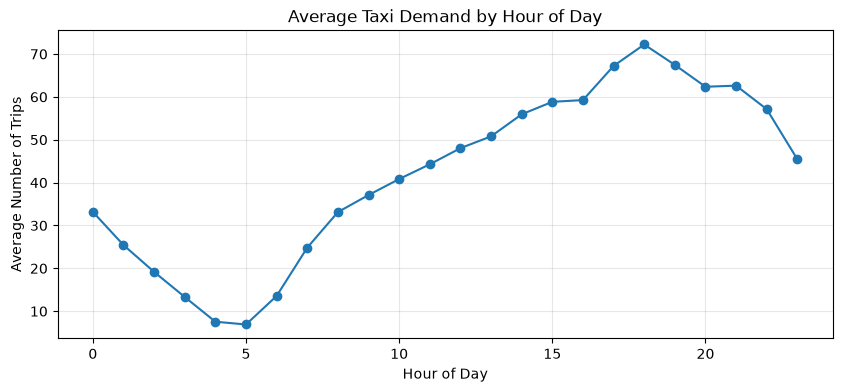

In [43]:
# Average Taxi Demand by Hour of Day

hourly_pattern = (
    hourly_df.groupby(hourly_df["pickup_hour"].dt.hour)["trip_count"]
    .mean()
)

hourly_pattern.plot(figsize=(10,4), marker="o")

plt.title("Average Taxi Demand by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Number of Trips")
plt.grid(alpha=0.3)
plt.show()

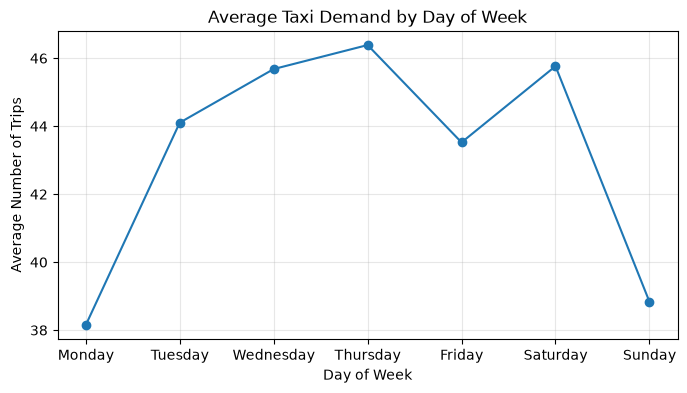

In [44]:
# Average Taxi Demand by Day of Week

day_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

daily_pattern = (
    hourly_df.assign(
        day=hourly_df["pickup_hour"].dt.day_name()
    )
    .groupby("day")["trip_count"]
    .mean()
    .reindex(day_order)
)

plt.figure(figsize=(8,4))
plt.plot(daily_pattern.index, daily_pattern.values, marker="o")

plt.title("Average Taxi Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Number of Trips")
plt.grid(alpha=0.3)

plt.show()

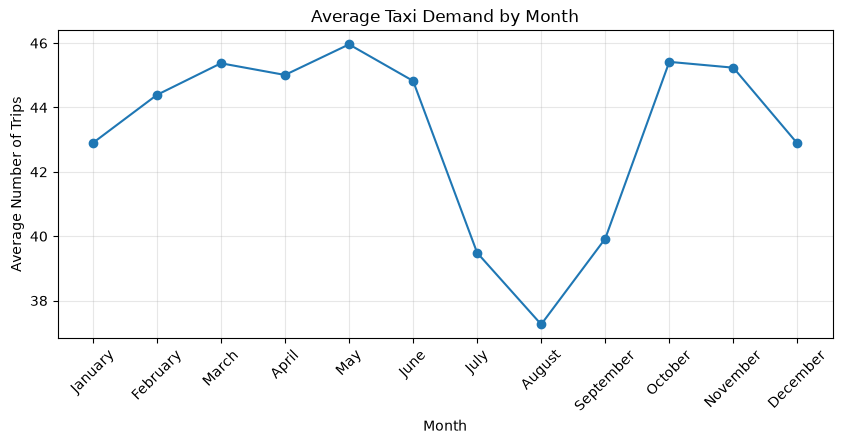

In [45]:
# Average Taxi Demand by Month

month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_pattern = (
    hourly_df.assign(
        month=hourly_df["pickup_hour"].dt.month_name()
    )
    .groupby("month")["trip_count"]
    .mean()
    .reindex(month_order)
)

plt.figure(figsize=(10,4))
plt.plot(monthly_pattern.index, monthly_pattern.values, marker="o")

plt.title("Average Taxi Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Number of Trips")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

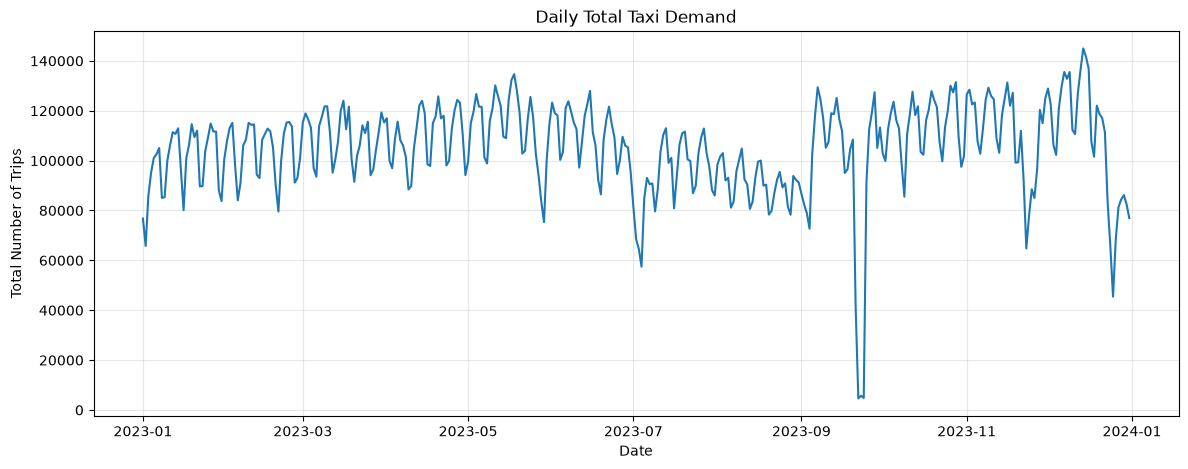

In [46]:
# Daily Total Demand -Time Series

daily_demand = (
    hourly_df.groupby(hourly_df["pickup_hour"].dt.date)["trip_count"]
    .sum()
)

plt.figure(figsize=(14,5))
plt.plot(daily_demand.index, daily_demand.values)

plt.title("Daily Total Taxi Demand")
plt.xlabel("Date")
plt.ylabel("Total Number of Trips")
plt.grid(alpha=0.3)

plt.show()

In [47]:
# The graph above looks weird as number of trips in sept drop by alot which is not normal (85 % + lower)

daily_demand = (
    hourly_df.groupby(hourly_df["pickup_hour"].dt.date)["trip_count"]
    .sum()
)

daily_demand.nsmallest(10)

pickup_hour
2023-09-22     4633
2023-09-24     4813
2023-09-23     5732
2023-09-21    41939
2023-12-25    45466
2023-07-04    57463
2023-07-03    64545
2023-11-23    64781
2023-12-24    65697
2023-01-02    65777
Name: trip_count, dtype: int64

In [48]:
# re read the original sept parquet file and investigate the issue
sep_df = pd.read_parquet(
    r"C:\Users\semee\Desktop\calibraxTA\Dataset\yellow_tripdata_2023-09.parquet",
    columns=["tpep_pickup_datetime", "PULocationID"]
)

sep_df["date"] = sep_df["tpep_pickup_datetime"].dt.date

daily_counts = (
    sep_df.groupby("date")
          .size()
          .sort_index()
)

daily_counts.nsmallest(10)

date
2008-12-31        2
2009-01-01        4
2023-10-01        8
2023-08-31       18
2023-09-22     4633
2023-09-24     4813
2023-09-23     5732
2023-09-21    41939
2023-09-04    72691
2023-09-03    79000
dtype: int64

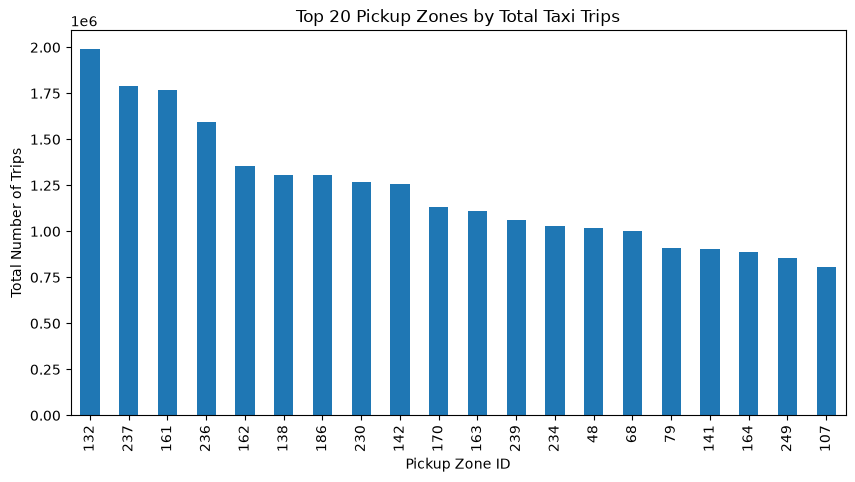

In [49]:
# Top 20 Pickup Zones

top_zone = (
    hourly_df.groupby("PULocationID")["trip_count"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(10,5))
top_zone.plot(kind="bar")

plt.title("Top 20 Pickup Zones by Total Taxi Trips")
plt.xlabel("Pickup Zone ID")
plt.ylabel("Total Number of Trips")

plt.show()

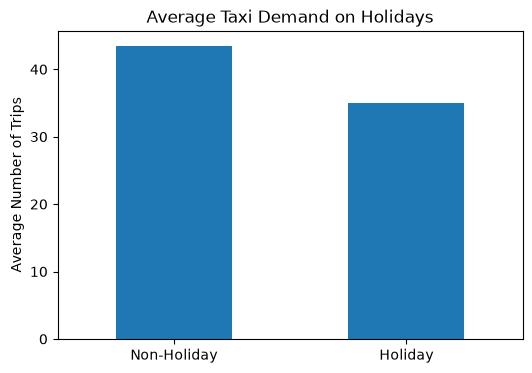

In [50]:
# Holiday vs Non-Holiday

holiday_pattern = (
    hourly_df.groupby("is_holiday")["trip_count"]
    .mean()
)

holiday_pattern.index = ["Non-Holiday", "Holiday"]

plt.figure(figsize=(6,4))
holiday_pattern.plot(kind="bar")

plt.title("Average Taxi Demand on Holidays")
plt.xlabel("")
plt.ylabel("Average Number of Trips")
plt.xticks(rotation=0)

plt.show()

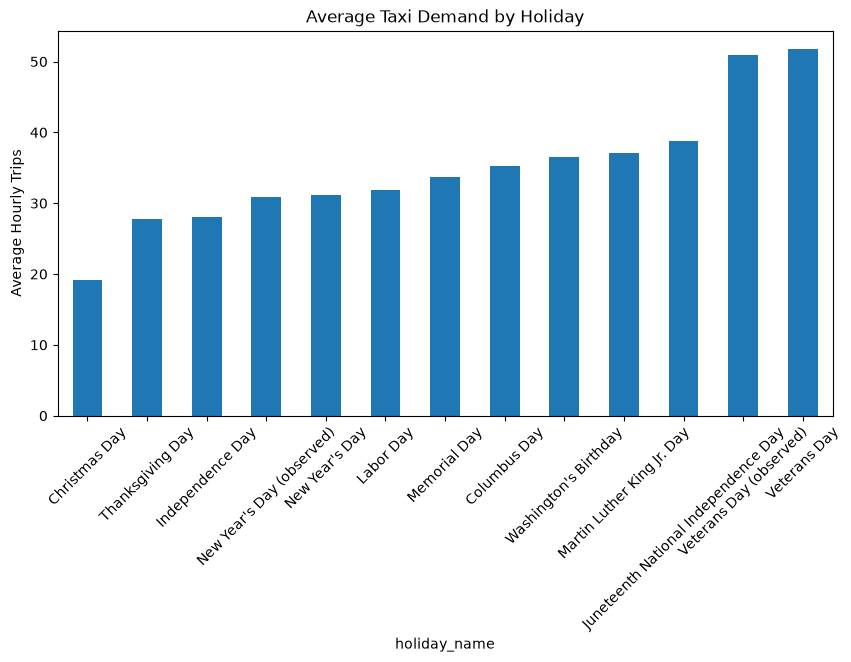

In [51]:
# Individual Holidays comparison

holiday_summary = (
    hourly_df[hourly_df["is_holiday"] == 1]
    .groupby("holiday_name")["trip_count"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,5))
holiday_summary.plot(kind="bar")
plt.ylabel("Average Hourly Trips")
plt.title("Average Taxi Demand by Holiday")
plt.xticks(rotation=45)
plt.show()

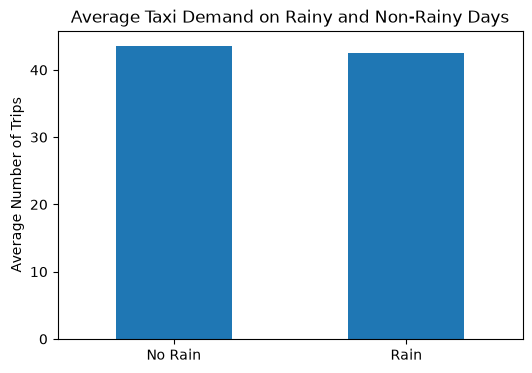

In [52]:
# Rainy vs Non-Rainy Days
hourly_df["rainy_day"] = (hourly_df["PRCP (Inches)"] > 0).astype(int)

rain_pattern = (
    hourly_df.groupby("rainy_day")["trip_count"]
    .mean()
)

rain_pattern.index = ["No Rain", "Rain"]

plt.figure(figsize=(6,4))
rain_pattern.plot(kind="bar")

plt.title("Average Taxi Demand on Rainy and Non-Rainy Days")
plt.xlabel("")
plt.ylabel("Average Number of Trips")
plt.xticks(rotation=0)

plt.show()

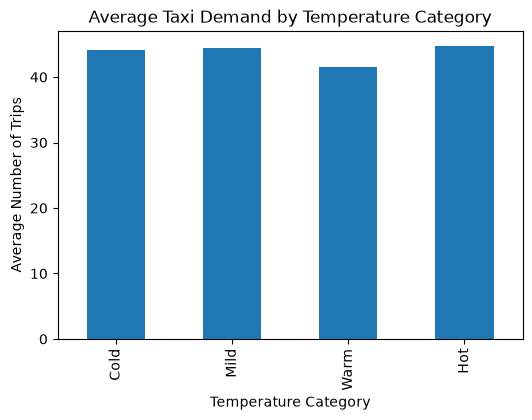

In [53]:
# Temperature Categories

hourly_df["temp_category"] = pd.cut(
    hourly_df["TMAX (Degrees Fahrenheit)"],
    bins=[0, 50, 70, 90, 120],
    labels=["Cold", "Mild", "Warm", "Hot"]
)

temp_pattern = (
    hourly_df.groupby("temp_category")["trip_count"]
    .mean()
)

temp_pattern.plot(kind="bar", figsize=(6,4))

plt.title("Average Taxi Demand by Temperature Category")
plt.xlabel("Temperature Category")
plt.ylabel("Average Number of Trips")

plt.show()

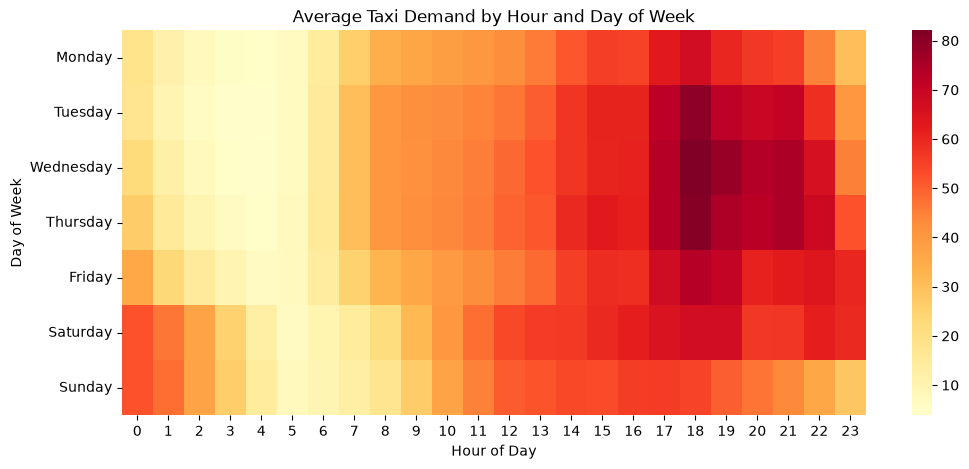

In [54]:
# generate heatmap for hour of day as well

heatmap_data = (
    hourly_df.assign(
        Day=hourly_df["pickup_hour"].dt.day_name(),
        Hour=hourly_df["pickup_hour"].dt.hour
    )
    .pivot_table(
        values="trip_count",
        index="Day",
        columns="Hour",
        aggfunc="mean"
    )
)

heatmap_data = heatmap_data.reindex([
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
])

plt.figure(figsize=(12,5))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd"
)

plt.title("Average Taxi Demand by Hour and Day of Week")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.show()

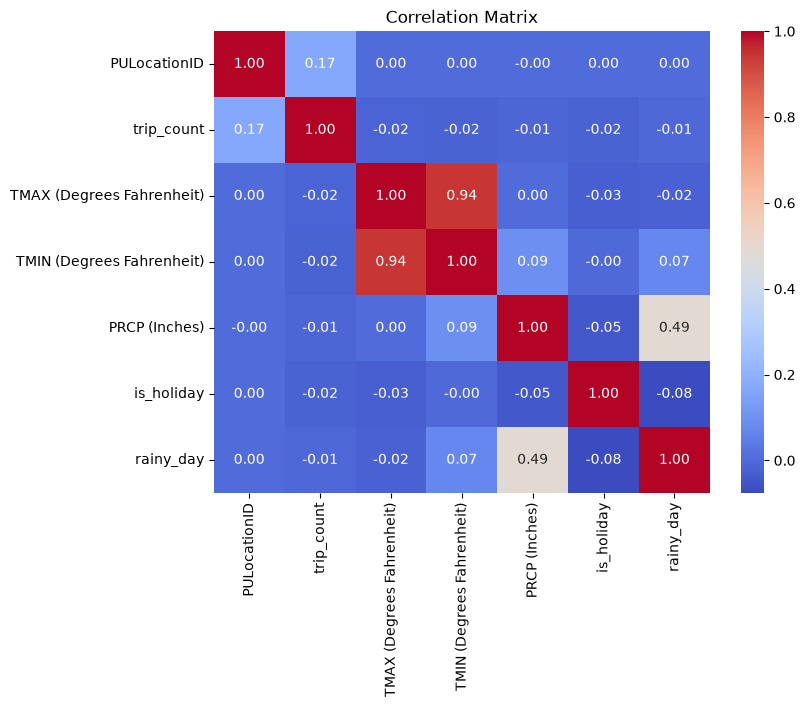

In [55]:
# take a look at correlation heatmap, which measures linear relationships but yes it cant capture nonlinear effects or interactions

corr = hourly_df.select_dtypes(include="number").corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

**Data from September 21–24 2023** were suspect to be incomplete, so to avoid bringing negative impact to the model later, will double analyse and remove them from the dataset.

In [56]:
check_dates = pd.to_datetime([
    "2023-09-21",
    "2023-09-22",
    "2023-09-23",
    "2023-09-24"
])

hourly_df.loc[
    hourly_df["date"].isin(check_dates)
].groupby("date").agg(
    total_trips=("trip_count", "sum"),
    hours_present=("pickup_hour", lambda x: x.dt.hour.nunique()),
    zones_present=("PULocationID", "nunique")
)

,total_trips,hours_present,zones_present
date,,,
2023-09-21,41939,24,221
2023-09-22,4633,24,145
2023-09-23,5732,24,143
2023-09-24,4813,24,150


In [57]:
# as 21st Sept looks better compare to 22 until 24, still significant lower, so do a comparison with previous day and see
compare = (
    hourly_df[
        hourly_df["date"].isin(
            pd.to_datetime(["2023-09-20", "2023-09-21"])
        )
    ]
    .groupby([
        hourly_df["pickup_hour"].dt.date,
        hourly_df["pickup_hour"].dt.hour
    ])["trip_count"]
    .sum()
    .unstack(0)
)

compare

pickup_hour,2023-09-20,2023-09-21
pickup_hour,,
0,1991,2577
1,828,1196
2,446,677
3,291,419
4,297,431
5,705,731
6,1997,2000
7,4118,4290
8,4923,5131


In [58]:
# Since 21 Sept 's half day data is obviously incomplete, will remove it from dataset as well

incomplete_dates = pd.to_datetime([
    "2023-09-21",
    "2023-09-22",
    "2023-09-23",
    "2023-09-24"
])

hourly_df = hourly_df[
    ~hourly_df["date"].isin(incomplete_dates)
].copy()

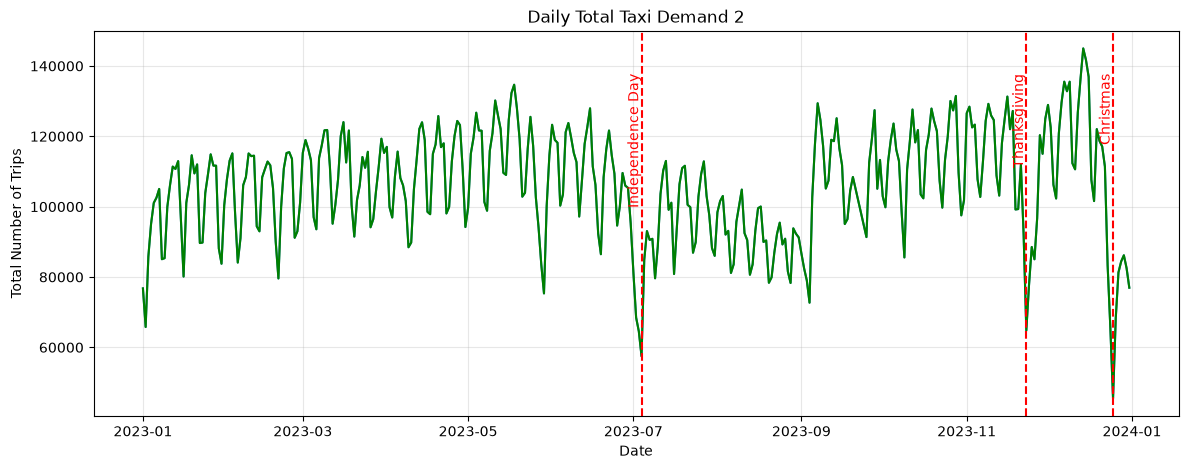

In [59]:
# Daily Total Demand - Time Series after removed 4 dates and check other local low region is it due to holiday

daily_demand = (
    hourly_df.groupby(hourly_df["pickup_hour"].dt.date)["trip_count"]
    .sum()
)

plt.figure(figsize=(14,5))
plt.plot(daily_demand.index, daily_demand.values)

plt.title("Daily Total Taxi Demand 2")
plt.xlabel("Date")
plt.ylabel("Total Number of Trips")
plt.grid(alpha=0.3)
plt.plot(daily_demand.index, daily_demand.values, color="green")

# Position for annotation
y_value = daily_demand.max() * 0.95

# Christmas
plt.axvline(pd.Timestamp("2023-12-25"), color="red", linestyle="--")
plt.text(pd.Timestamp("2023-12-25"), y_value, "Christmas",
         rotation=90, color="red", ha="right", va="top")

# Independence Day
plt.axvline(pd.Timestamp("2023-07-04"), color="red", linestyle="--")
plt.text(pd.Timestamp("2023-07-04"), y_value, "Independence Day",
         rotation=90, color="red", ha="right", va="top")

# Thanksgiving
plt.axvline(pd.Timestamp("2023-11-23"), color="red", linestyle="--")
plt.text(pd.Timestamp("2023-11-23"), y_value, "Thanksgiving",
         rotation=90, color="red", ha="right", va="top")

plt.show()

## Feature Engineering

Create Time-Based Features as this is a time-series forcasting problem

In [60]:
# create hour only column
hourly_df["hour"] = hourly_df["pickup_hour"].dt.hour

# create day of week only column, ie Monday = 0
hourly_df["day_of_week"] = hourly_df["pickup_hour"].dt.dayofweek

# create month only column
hourly_df["month"] = hourly_df["pickup_hour"].dt.month

# create week of year column
hourly_df["week_of_year"] = hourly_df["pickup_hour"].dt.isocalendar().week.astype(int)

# create is weeknd or not column
hourly_df["is_weekend"] = hourly_df["day_of_week"].isin([5, 6]).astype(int)

Create Lag Features

In [61]:
# Lag features, since here is trying to forecasting per zone, so create lags within each zone

hourly_df = hourly_df.sort_values(["PULocationID", "pickup_hour"])

In [62]:
# LAG will shows the trip_count in the same taxi zone in the previous hours

# previous hour
hourly_df["lag_1"] = (
    hourly_df
    .groupby("PULocationID")["trip_count"]
    .shift(1)
)

# past 2 hours
hourly_df["lag_2"] = (
    hourly_df
    .groupby("PULocationID")["trip_count"]
    .shift(2)
)

# same hour yesterday
hourly_df["lag_24"] = (
    hourly_df
    .groupby("PULocationID")["trip_count"]
    .shift(24)
)

Create the Target

In [63]:
# since here is going to predict the demand 1 hours ahead

# Sort by zone and time
hourly_df = hourly_df.sort_values(
    ["PULocationID", "pickup_hour"]
).copy()

# create target
hourly_df["target"] = (
    hourly_df
    .groupby("PULocationID")["trip_count"]
    .shift(-1)
)

In [64]:
# Check the actual time of the target row
hourly_df["target_time_check"] = (
    hourly_df
    .groupby("PULocationID")["pickup_hour"]
    .shift(-1)
)

# see if the target gap is 1 hours
hourly_df["target_gap_hours"] = (
    hourly_df["target_time_check"] - hourly_df["pickup_hour"]
).dt.total_seconds() / 3600

hourly_df["target_gap_hours"].value_counts().head()

target_gap_hours
1.0    684050
2.0     64555
3.0     31315
4.0     18997
5.0     13079
Name: count, dtype: int64

Some taxi zones might have hours with zero trips after aggregation, so when doing shift(-1) if might move to 2 or more hours later.
So here filtering to target_gap_hours == 1 only to ensures every training example truly matches the objective of predicting 1 hours ahead

In [67]:
# Lags and the target naturally create missing values at the beginning and end of each zone's time series, so remove them
hourly_df = hourly_df[
    hourly_df["target_gap_hours"] == 1
].copy()

In [69]:
# Remove temporary columns
hourly_df.drop(
    columns=["target_time_check", "target_gap_hours"],
    inplace=True
)

In [70]:
# Remove rows with missing lag features or target
hourly_df = hourly_df.dropna().reset_index(drop=True)

# 4. Modeling

In [80]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
import numpy as np

In [71]:
hourly_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 681329 entries, 0 to 681328
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   pickup_hour                681329 non-null  datetime64[us]
 1   PULocationID               681329 non-null  int64         
 2   trip_count                 681329 non-null  int64         
 3   date                       681329 non-null  datetime64[us]
 4   TMAX (Degrees Fahrenheit)  681329 non-null  float64       
 5   TMIN (Degrees Fahrenheit)  681329 non-null  float64       
 6   PRCP (Inches)              681329 non-null  float64       
 7   is_holiday                 681329 non-null  int64         
 8   holiday_name               681329 non-null  str           
 9   rainy_day                  681329 non-null  int64         
 10  temp_category              681329 non-null  category      
 11  hour                       681329 non-null  int32         
 12 

## Select Features & Target

In [72]:
# Select features and define target
# columns that not useful will be removed
feature_cols = [
    "PULocationID",
    "hour",
    "day_of_week",
    "month",
    "week_of_year",
    "is_weekend",
    "TMAX (Degrees Fahrenheit)",
    "TMIN (Degrees Fahrenheit)",
    "PRCP (Inches)",
    "is_holiday",
    "rainy_day",
    "lag_1",
    "lag_2",
    "lag_24"
]

In [73]:
X = hourly_df[feature_cols]
y = hourly_df["target"]

## Train-Test Set Split

In [74]:
# 80% training, 20% testing
split_idx = int(len(hourly_df) * 0.8)

train_df = hourly_df.iloc[:split_idx]
test_df = hourly_df.iloc[split_idx:]

# Features
X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

# Target
y_train = train_df["target"]
y_test = test_df["target"]

print(f"Training samples: {len(train_df):,}")
print(f"Testing samples : {len(test_df):,}")

Training samples: 545,063
Testing samples : 136,266


## Linear Regression (baseline)

In [78]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[ 0.02,-0.17,-0.31,..., 0.77,-0.34, 0.49]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](14,)","['PULocationID','hour','day_of_week',...,'lag_1','lag_2','lag_24']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.615
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)


In [79]:
lr_pred = lr_model.predict(X_test)

In [82]:
# evaluate the model with classic regression metrics

mae = mean_absolute_error(y_test, lr_pred)
rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
mape = mean_absolute_percentage_error(y_test, lr_pred)

print(f"Linear Regression (Baseline)")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2%}")

Linear Regression (Baseline)
MAE : 22.18
RMSE: 37.08
MAPE: 171.51%


The Linear Regression model achieved an MAE of 22.18 and an RMSE of 37.08. Although the MAPE was relatively high (171.51%), this is likely due to many observations having very low taxi demand, where small absolute errors translate into large percentage errors. Therefore, MAE and RMSE were considered more representative evaluation metrics for this forecasting task.

## XGBoost

In [ ]:
#!pip install xgboost

In [88]:
import xgboost
print(xgboost.__version__)
from xgboost import XGBRegressor

3.3.0


In [93]:
# define xgb
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=123,
    eval_metric="rmse",
    early_stopping_rounds=20
)

In [ ]:
# training xgb
xgb_model.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_test, y_test)
    ],
    verbose=10 # print every 10 rounds
)

In [95]:
# Make predictions for xgb
xgb_pred = xgb_model.predict(X_test)

In [96]:
mae = mean_absolute_error(y_test, xgb_pred)
rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
mape = mean_absolute_percentage_error(y_test, xgb_pred)

print("XGBoost")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2%}")

XGBoost
MAE : 17.08
RMSE: 30.82
MAPE: 67.96%


# 5. Evaluation

XGBoost model outperformed the Linear Regression baseline based on evaluation metrics such as MAE, RMSE and MAPE. 

The MAE decreased by approximately 23%, while the RMSE decreased by approximately 17%, indicating more accurate predictions and improved handling of larger prediction errors.

Although MAPE remained relatively high due to low-demand observations, it was substantially reduced compared with the baseline model.

## Feature Importance

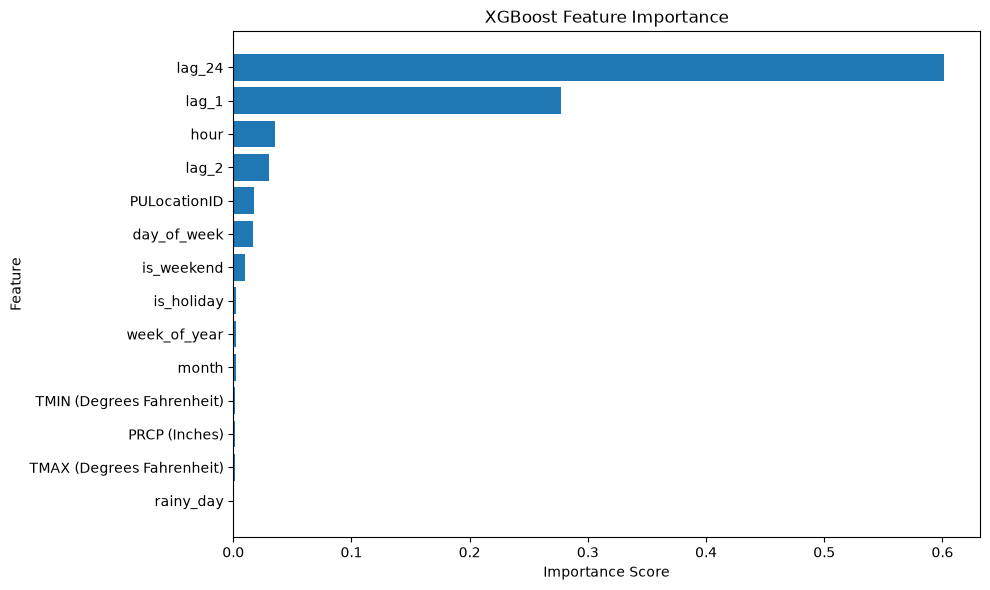

In [99]:
# check which feature have higher weight

feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)
plt.gca().invert_yaxis()

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Prediction on Top 5 NYC Taxi Zone

Combine the taxi_zone_lookup csv file to evalution so can know where the zone is located where

In [112]:
zone_lookup_path = r"C:\Users\semee\Desktop\calibraxTA\Dataset\taxi_zone_lookup.csv"
zone_lookup = pd.read_csv(zone_lookup_path)

zone_lookup.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [109]:
# Create evaluation dataframe with predictions
evaluation_df = test_df.copy()
evaluation_df["prediction"] = xgb_pred

evaluation_df = evaluation_df.merge(
    zone_lookup,
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

In [113]:
# Find the top 5 busiest zones based on total actual trip demand

top_5_zones = (
    evaluation_df.groupby(
        ["PULocationID", "Borough", "Zone", "service_zone"],
        dropna=False
    )["target"]
    .sum()
    .nlargest(5)
    .reset_index()
)

# Extract the Top 5 zone IDs
top_5_zone_ids = top_5_zones["PULocationID"].tolist()

print(top_5_zone_ids)

[237, 236, 239, 234, 249]


In [114]:
# Create a dictionary for plot titles (so it can show the zone name instead of id)
zone_labels = (
    top_5_zones
    .set_index("PULocationID")
    .apply(
        lambda row: f"{row['Zone']} ({row['Borough']})",
        axis=1
    )
    .to_dict()
)

zone_labels

{237: 'Upper East Side South (Manhattan)',
 236: 'Upper East Side North (Manhattan)',
 239: 'Upper West Side South (Manhattan)',
 234: 'Union Sq (Manhattan)',
 249: 'West Village (Manhattan)'}

In [115]:
window_hours = 168      # wanna show 7 days plot
random_seed = 123

# Get all timestamps in the test set
available_times = np.sort(evaluation_df["pickup_hour"].unique())

# Randomly choose a starting point
rng = np.random.default_rng(random_seed)
start_index = rng.integers(
    0,
    len(available_times) - window_hours + 1
)

selected_times = available_times[
    start_index:start_index + window_hours
]

print(selected_times[0], "to", selected_times[-1])

2023-01-07T10:00:00.000000 to 2023-01-14T09:00:00.000000


In [116]:
# Filter to the Top 5 zones and selected timeframe
plot_df = evaluation_df[
    evaluation_df["PULocationID"].isin(top_5_zone_ids)
    & evaluation_df["pickup_hour"].isin(selected_times)
].copy()

In [117]:
plot_df[
    ["pickup_hour", "PULocationID", "Zone", "target", "prediction"]
].head()

,pickup_hour,PULocationID,Zone,target,prediction
14744,2023-01-07 10:00:00,234,Union Sq,111.0,113.902451
14745,2023-01-07 11:00:00,234,Union Sq,154.0,133.814987
14746,2023-01-07 12:00:00,234,Union Sq,189.0,127.732597
14747,2023-01-07 13:00:00,234,Union Sq,166.0,160.793060
14748,2023-01-07 14:00:00,234,Union Sq,203.0,194.129211


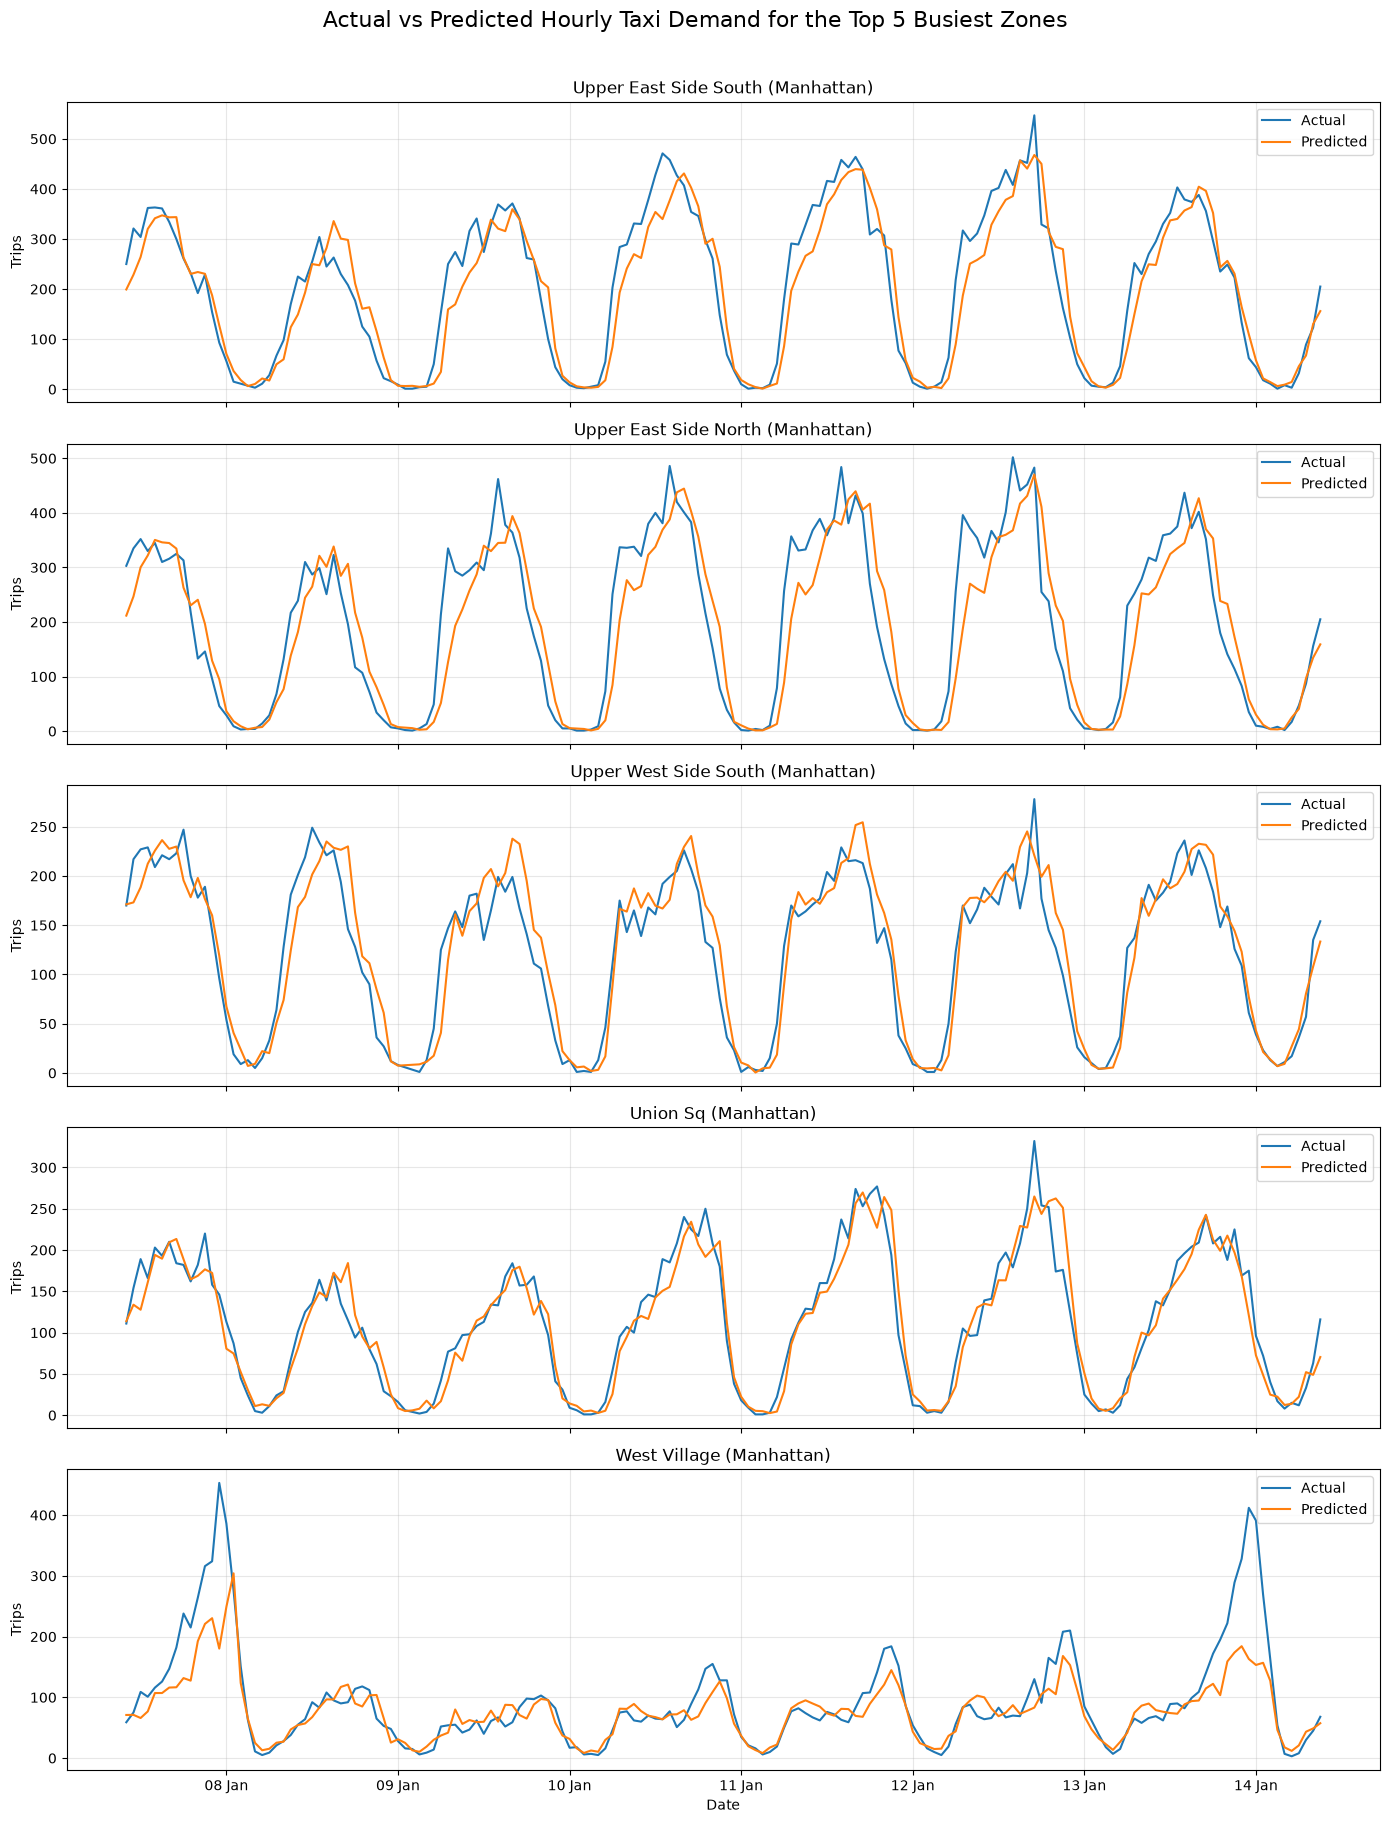

In [121]:
# Create 5 vertically stacked plots for all five zones

fig, axes = plt.subplots(
    5, 1,
    figsize=(14, 18),
    sharex=True
)

for ax, zone_id in zip(axes, top_5_zone_ids):

    # Select one zone
    zone_data = (
        plot_df[plot_df["PULocationID"] == zone_id]
        .sort_values("pickup_hour")
    )

    # Plot actual and predicted demand
    ax.plot(
        zone_data["pickup_hour"],
        zone_data["target"],
        label="Actual"
    )

    ax.plot(
        zone_data["pickup_hour"],
        zone_data["prediction"],
        label="Predicted"
    )

    ax.set_title(zone_labels[zone_id])
    ax.set_ylabel("Trips")
    ax.legend()
    ax.grid(alpha=0.3)

# Format the date labels
axes[-1].xaxis.set_major_locator(mdates.DayLocator())
axes[-1].xaxis.set_major_formatter(
    mdates.DateFormatter("%d %b")
)

axes[-1].set_xlabel("Date")

fig.suptitle(
    "Actual vs Predicted Hourly Taxi Demand for the Top 5 Busiest Zones",
    fontsize=16,
    y=1.01
)

plt.tight_layout()
plt.show()